In [1]:
#Carregar as bibliotecas

import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import os
import cv2
from tqdm import tqdm
import random
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
from tensorflow.math import confusion_matrix
import seaborn as sns
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import numpy as np
tf.random.set_seed(3)

2026-04-11 01:33:14.907626: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


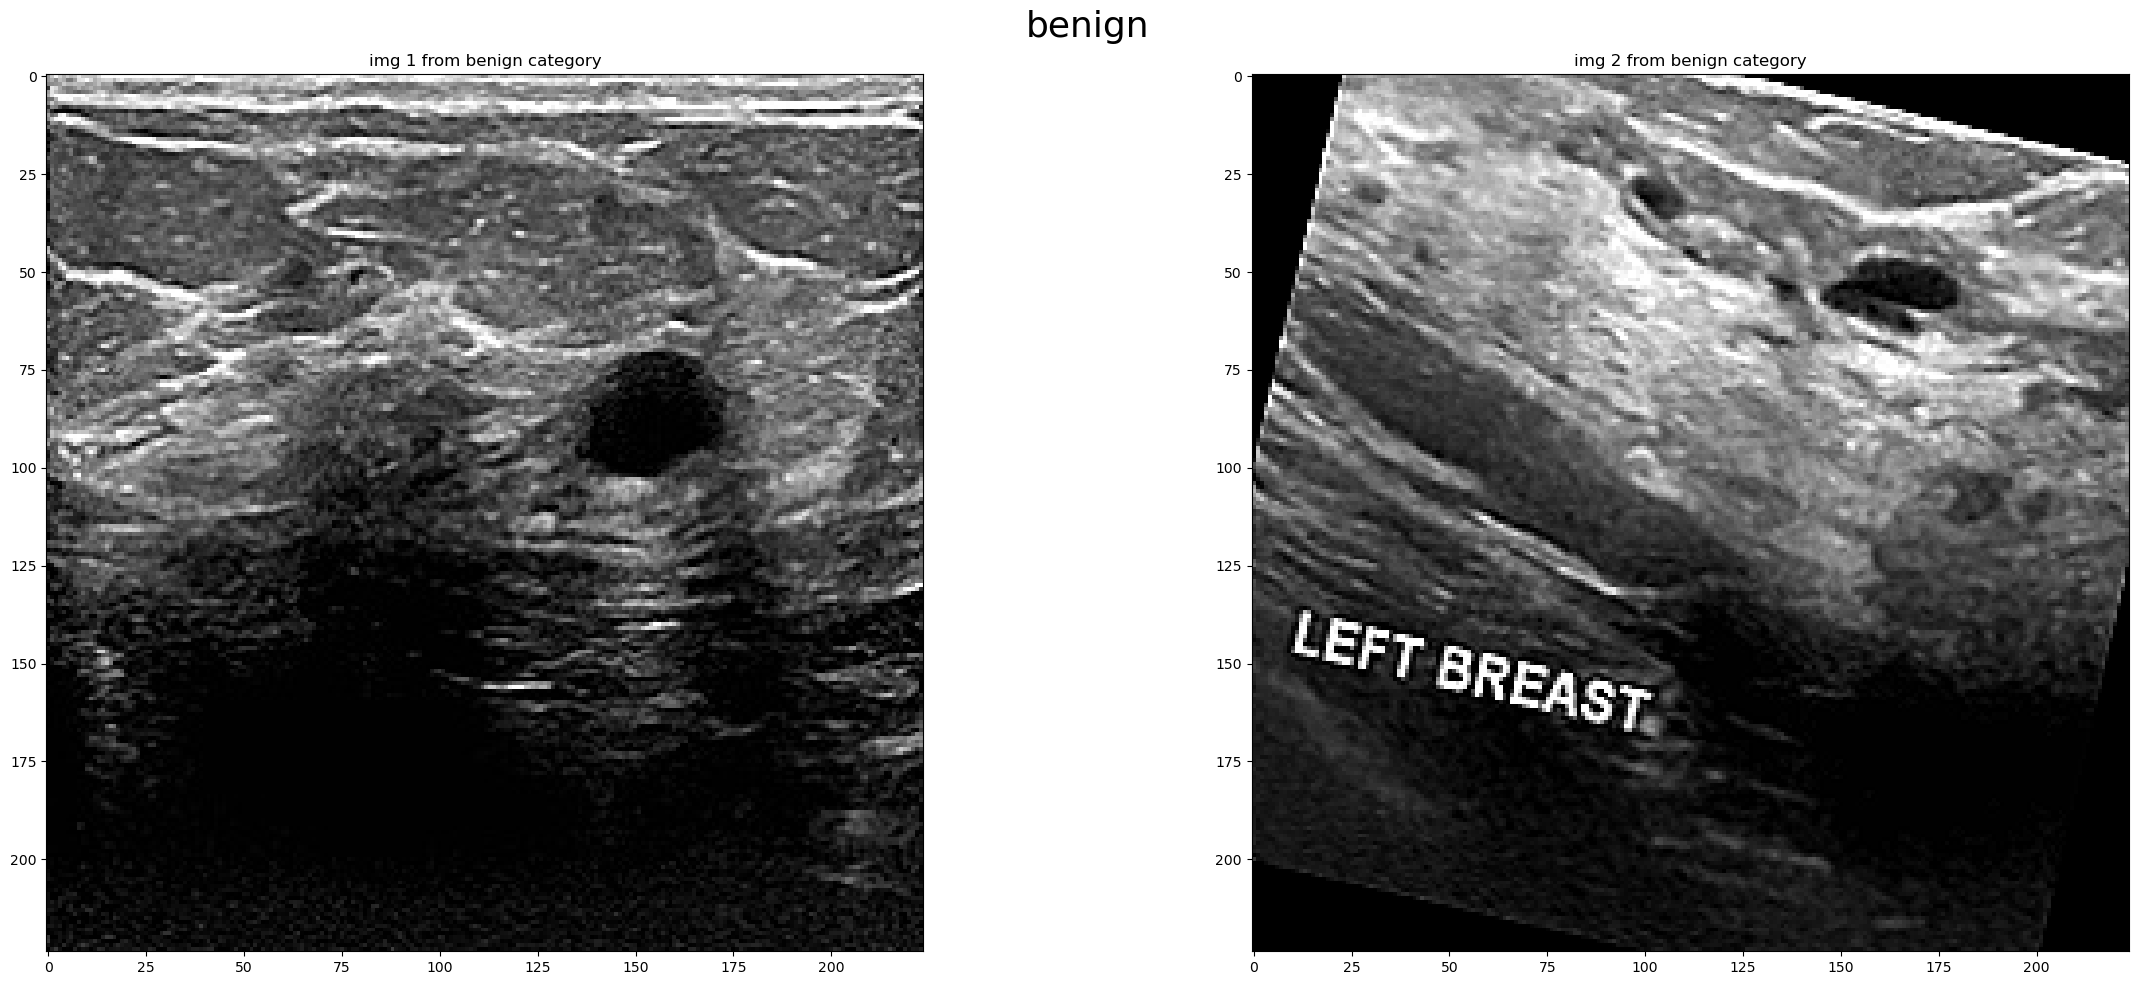

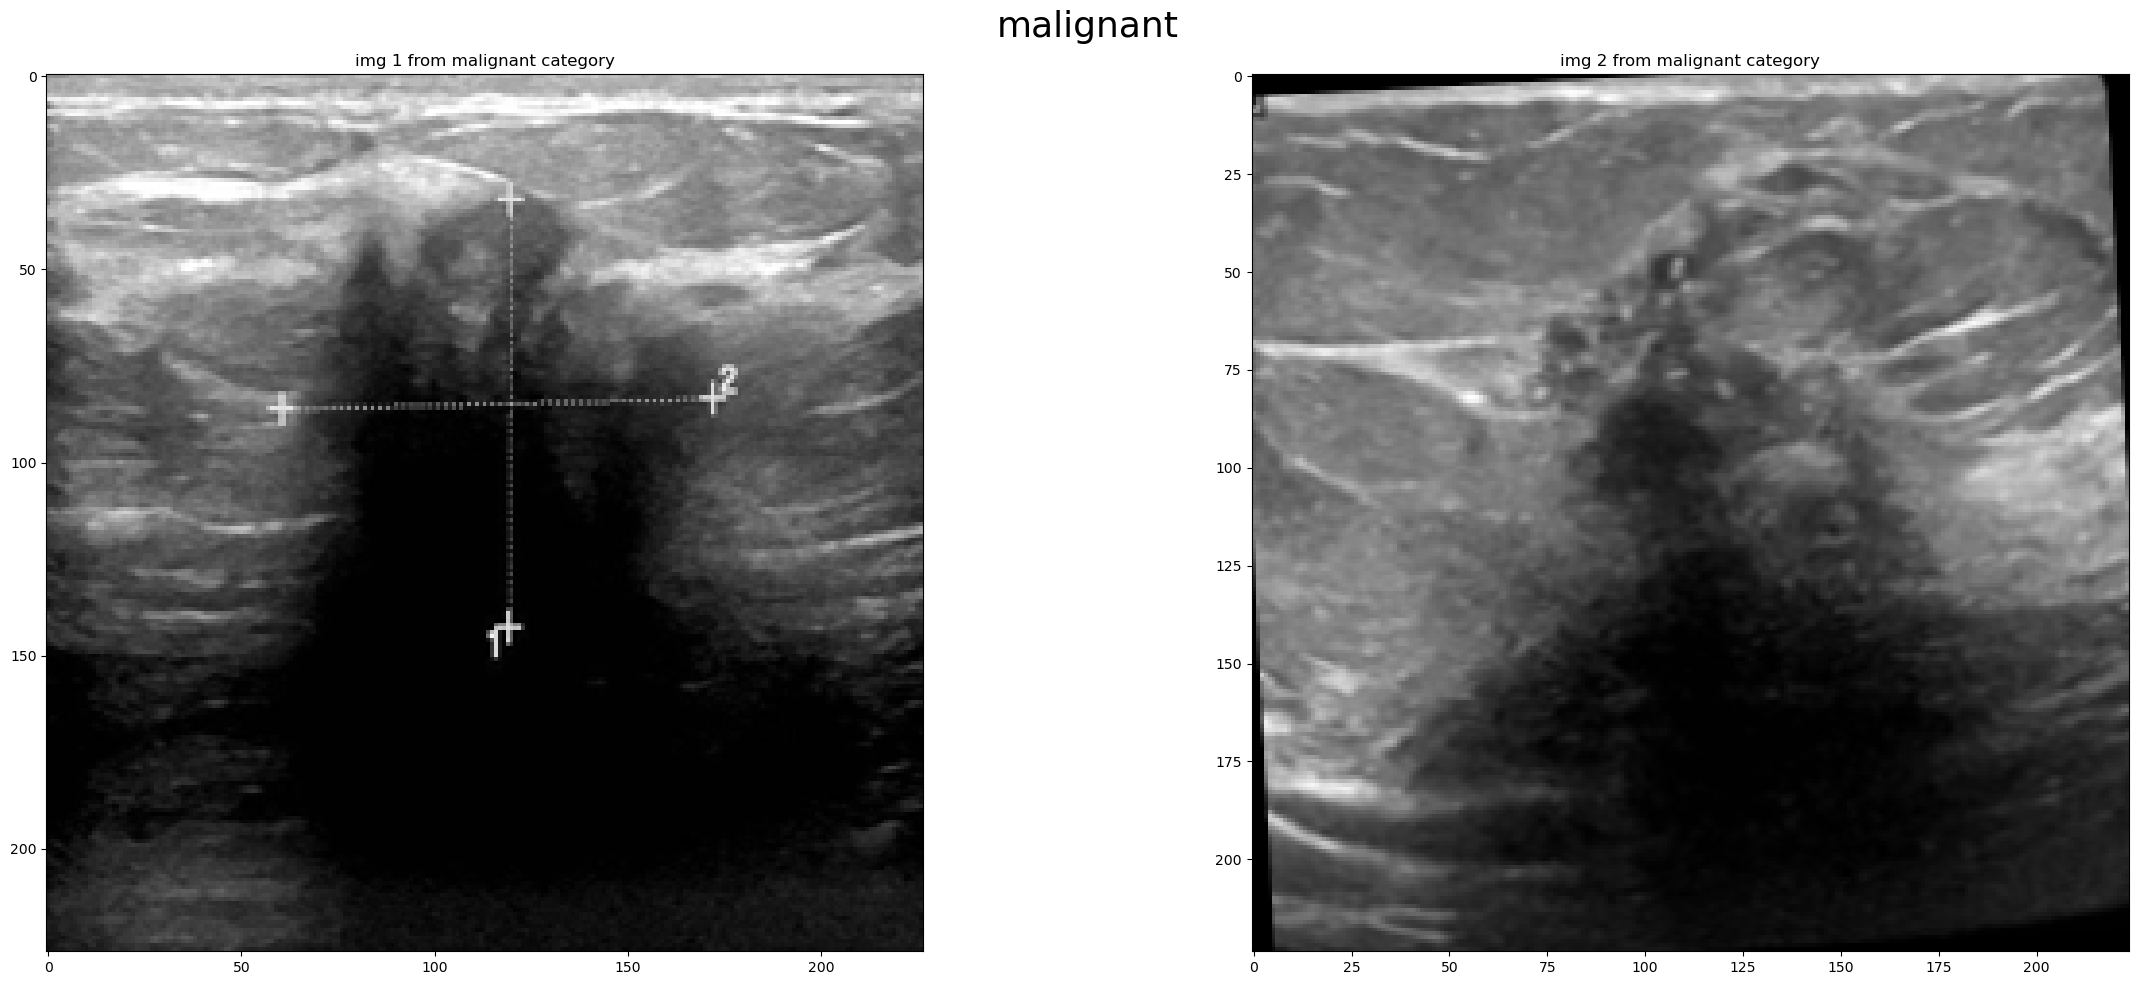

In [2]:
#Dados sobre conjunto de imagens de ultrassom de mama que contém 2 Classes [benigno, maligno] Exibindo 2 imagens de cada classe

import os
import cv2
import matplotlib.pyplot as plt

# Novo caminho da base de dados
folder_name = '/home/pc/Projeto/Ultrasound Breast Images for Breast Cancer/ultrasound_dataset/train'
files_names = ['benign', 'malignant']  # Apenas as duas classes desejadas

for file in files_names:
    path = os.path.join(folder_name, file)
    x = 0
    fig, axes = plt.subplots(1, 2, figsize=(25, 10))  
    
    for img in os.listdir(path):
        if not img.lower().endswith(('.png', '.jpg', '.jpeg')):
            continue  # Ignora arquivos que não são imagens

        img_path = os.path.join(path, img)
        if not os.path.isfile(img_path):
            continue  # Garante que é um arquivo

        img_array = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img_array is None:
            continue  # Ignora arquivos corrompidos ou inválidos

        axes[x].imshow(img_array, cmap='gray')
        axes[x].set_title(f"img {x+1} from {file} category")
        x += 1
        if x == 2: 
            break

    plt.suptitle(file, fontsize=26)
    plt.tight_layout()
    plt.show()

In [3]:
# Carregando dados

import os
import cv2
from tqdm import tqdm

# Caminho para a pasta contendo as imagens de treino
folder_name = '/home/pc/Projeto/Ultrasound Breast Images for Breast Cancer/ultrasound_dataset/train'

# Classes que queremos carregar
files_names = ['benign', 'malignant']

# Tamanho das imagens
img_sz = 224

# Lista para armazenar os dados de treino
training_data = []

def create_training_data():
    for file in files_names:
        path = os.path.join(folder_name, file)
        class_num = files_names.index(file)  # 0 para benign, 1 para malignant
        print(file, class_num)

        for img in tqdm(os.listdir(path)):
            img_path = os.path.join(path, img)

            # Filtros para evitar imagens indesejadas
            if not img.lower().endswith('.png'):
                continue
            if not os.path.isfile(img_path):
                continue

            img_array = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            if img_array is None:
                continue  # evita erro se a imagem estiver corrompida

            new_array = cv2.resize(img_array, (img_sz, img_sz))
            training_data.append([new_array, class_num])

# Executar a função
create_training_data()


benign 0


100%|█████████████████████████████████████| 4074/4074 [00:02<00:00, 1504.24it/s]


malignant 1


100%|█████████████████████████████████████| 4042/4042 [00:03<00:00, 1249.48it/s]


In [4]:
# Os dados têm imagens benignas e malignas. Embaralhando e exibindo as primeiras 20 classes

import random

# Embaralha os dados de treino
random.shuffle(training_data)

# Exibe as primeiras 30 amostras com suas classes
for i in range(30):
    print(f"Sample {i+1}:")
    print("Class number:", training_data[i][1], "\n")


Sample 1:
Class number: 0 

Sample 2:
Class number: 1 

Sample 3:
Class number: 1 

Sample 4:
Class number: 1 

Sample 5:
Class number: 1 

Sample 6:
Class number: 1 

Sample 7:
Class number: 1 

Sample 8:
Class number: 1 

Sample 9:
Class number: 1 

Sample 10:
Class number: 1 

Sample 11:
Class number: 1 

Sample 12:
Class number: 1 

Sample 13:
Class number: 1 

Sample 14:
Class number: 0 

Sample 15:
Class number: 0 

Sample 16:
Class number: 0 

Sample 17:
Class number: 0 

Sample 18:
Class number: 1 

Sample 19:
Class number: 0 

Sample 20:
Class number: 1 

Sample 21:
Class number: 1 

Sample 22:
Class number: 0 

Sample 23:
Class number: 1 

Sample 24:
Class number: 0 

Sample 25:
Class number: 1 

Sample 26:
Class number: 1 

Sample 27:
Class number: 0 

Sample 28:
Class number: 1 

Sample 29:
Class number: 1 

Sample 30:
Class number: 0 



In [5]:
import numpy as np

X = []
y = []

# Percorre as amostras de treinamento
for feature, label in training_data:
    X.append(feature)
    y.append(label)

# Converte as listas em arrays numpy
X = np.array(X)
y = np.array(y)

# Adiciona a dimensão para o canal (escala de cinza)
X = np.expand_dims(X, axis=-1)  # Adiciona a dimensão do canal de cor (1 para grayscale)

# Verificando a forma de X e y
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")


X shape: (7352, 224, 224, 1)
y shape: (7352,)


In [6]:
from sklearn.model_selection import train_test_split

# Divisão dos dados em treino e teste (80% treino, 20% teste)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Verificar as formas dos conjuntos de dados
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)


(5881, 224, 224, 1)
(5881,)
(1471, 224, 224, 1)
(1471,)


In [7]:
# Valores únicos em y (Classes)

print(np.unique(y_train))

print(np.unique(y_test))

[0 1]
[0 1]


In [8]:
# Normalização para 0-1
X_train = X_train/255
X_test = X_test/255

In [13]:
import tensorflow as tf
from tensorflow.keras import layers, models

import tensorflow as tf
from tensorflow.keras import layers, models

def coord_attention(x, reduction=32):
    input_channels = x.shape[-1]

    # ----- Pooling -----
    h_pool = layers.Lambda(lambda z: tf.reduce_mean(z, axis=2, keepdims=True))(x)
    w_pool = layers.Lambda(lambda z: tf.reduce_mean(z, axis=1, keepdims=True))(x)

    w_pool = layers.Lambda(lambda z: tf.transpose(z, perm=[0, 2, 1, 3]))(w_pool)

    # ----- Concat -----
    y = layers.Concatenate(axis=1)([h_pool, w_pool])

    # ----- Bottleneck -----
    reduced_channels = max(8, input_channels // reduction)

    y = layers.Conv2D(reduced_channels, kernel_size=1,
                      padding='same',
                      use_bias=False,
                      kernel_initializer='he_normal')(y)

    y = layers.BatchNormalization()(y)
    y = layers.Activation('relu')(y)

    # ----- Split -----
    h, w = layers.Lambda(lambda z: tf.split(z, num_or_size_splits=2, axis=1))(y)

    w = layers.Lambda(lambda z: tf.transpose(z, perm=[0, 2, 1, 3]))(w)

    # ----- Attention maps -----
    h_att = layers.Conv2D(input_channels, kernel_size=1,
                          padding='same',
                          activation='sigmoid',
                          use_bias=False,
                          kernel_initializer='he_normal')(h)

    w_att = layers.Conv2D(input_channels, kernel_size=1,
                          padding='same',
                          activation='sigmoid',
                          use_bias=False,
                          kernel_initializer='he_normal')(w)

    # ----- Apply -----
    out = layers.Multiply()([x, h_att])
    out = layers.Multiply()([out, w_att])

    return out

# Agora o modelo com CoordAttention
import tensorflow as tf
from tensorflow.keras import layers, models

img_sz = 224

inputs = layers.Input(shape=(img_sz, img_sz, 1))

x = layers.Conv2D(32, (3, 3), padding='same', activation='relu')(inputs)
x = coord_attention(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D((2, 2))(x)

x = layers.Conv2D(64, (3, 3), padding='same', activation='relu')(x)
x = coord_attention(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D((2, 2))(x)

x = layers.Conv2D(128, (3, 3), dilation_rate=2, padding='same', activation='relu')(x)
x = coord_attention(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D((2, 2))(x)

x = layers.Conv2D(256, (3, 3), dilation_rate=2, padding='same', activation='relu')(x)
x = coord_attention(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D((2, 2))(x)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.4)(x)

x = layers.Dense(64, activation='relu')(x)

outputs = layers.Dense(2, activation='softmax')(x)

model = models.Model(inputs=inputs, outputs=outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [14]:
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_34 (Conv2D)  │ (None, 224, 224,  │        320 │ input_layer_4[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_41 (Lambda)  │ (None, 1, 224,    │          0 │ conv2d_34[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_40 (Lambda)  │ (None, 224, 1,    │          0 │ conv2d_34[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_42 (Lambda)  │ (None, 224, 1,    │          0 │ lambda_41[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_8       │ (None, 448, 1,    │          0 │ lambda_40[0][0],  │
│ (Concatenate)       │ 32)               │            │ lambda_42[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_35 (Conv2D)  │ (None, 448, 1, 8) │        256 │ concatenate_8[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 448, 1, 8) │         32 │ conv2d_35[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_8        │ (None, 448, 1, 8) │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_43 (Lambda)  │ [(None, 224, 1,   │          0 │ activation_8[0][… │
│                     │ 8), (None, 224,   │            │                   │
│                     │ 1, 8)]            │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_36 (Conv2D)  │ (None, 224, 1,    │        256 │ lambda_43[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_44 (Lambda)  │ (None, 1, 224, 8) │          0 │ lambda_43[0][1]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_16         │ (None, 224, 224,  │          0 │ conv2d_34[0][0],  │
│ (Multiply)          │ 32)               │            │ conv2d_36[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_37 (Conv2D)  │ (None, 1, 224,    │        256 │ lambda_44[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_17         │ (None, 224, 224,  │          0 │ multiply_16[0][0… │
│ (Multiply)          │ 32)               │            │ conv2d_37[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 224, 224,  │        128 │ multiply_17[0][0] │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_8     │ (None, 112, 112,  │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                 

 Total params: 442,690 (1.69 MB)

 Trainable params: 441,666 (1.68 MB)

 Non-trainable params: 1,024 (4.00 KB)

In [15]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(monitor='val_loss',  # ou 'val_accuracy'
                               patience=10,          # número de épocas sem melhora antes de parar
                               restore_best_weights=True)  # restaura os melhores pesos

history = model.fit(X_train, y_train,
                    epochs=50,
                    validation_split=0.2,
                    batch_size=8,
                    callbacks=[early_stopping])

2026-04-11 01:35:55.669079: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 944111616 exceeds 10% of free system memory.
2026-04-11 01:35:56.486529: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 944111616 exceeds 10% of free system memory.


Epoch 1/50


2026-04-11 01:35:59.661501: I external/local_xla/xla/service/service.cc:163] XLA service 0x7b39d8022c80 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-04-11 01:35:59.661516: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 3080 Ti, Compute Capability 8.6
2026-04-11 01:35:59.743682: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-04-11 01:36:00.270323: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 92000


 19/588 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.4560 - loss: 0.7538

I0000 00:00:1775882167.254722   25204 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


588/588 ━━━━━━━━━━━━━━━━━━━━ 19s 15ms/step - accuracy: 0.6241 - loss: 0.6534 - val_accuracy: 0.5650 - val_loss: 0.9337
Epoch 2/50
588/588 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.7330 - loss: 0.5258 - val_accuracy: 0.7876 - val_loss: 0.4477
Epoch 3/50
588/588 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.7843 - loss: 0.4600 - val_accuracy: 0.8139 - val_loss: 0.3869
Epoch 4/50
588/588 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.8090 - loss: 0.4022 - val_accuracy: 0.8105 - val_loss: 0.3922
Epoch 5/50
588/588 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.8471 - loss: 0.3529 - val_accuracy: 0.8683 - val_loss: 0.3016
Epoch 6/50
588/588 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.8590 - loss: 0.3151 - val_accuracy: 0.9099 - val_loss: 0.2204
Epoch 7/50
588/588 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.8881 - loss: 0.2677 - val_accuracy: 0.9269 - val_loss: 0.1745
Epoch 8/50
588/588 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.9115 - loss: 0.2164 - val_accuracy: 0.9320

In [16]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Accuarcy of the model is : {accuracy*100:.2f} %")

2026-04-11 01:39:23.256140: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-11 01:39:23.256157: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-11 01:39:23.689911: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_497', 4 bytes spill stores, 4 bytes spill loads

2026-04-11 01:39:23.921471: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Re

43/46 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9674 - loss: 0.0943

2026-04-11 01:39:26.316739: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-11 01:39:26.316757: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-11 01:39:26.906074: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_497', 8 bytes spill stores, 8 bytes spill loads

2026-04-11 01:39:27.160806: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Re

46/46 ━━━━━━━━━━━━━━━━━━━━ 6s 67ms/step - accuracy: 0.9675 - loss: 0.0929
Accuarcy of the model is : 96.80 %


In [17]:
from sklearn.metrics import confusion_matrix
import numpy as np

# Fazer a predição com o modelo
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# Gerar a matriz de confusão
conf_mat = confusion_matrix(y_test, y_pred_classes)



46/46 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step


In [18]:
y_pred = [np.argmax(i) for i in y_pred]
print(y_pred)

[np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1)

In [19]:
# Supondo que você tenha as classes "Benign" e "Malignant"
comparison_df = pd.DataFrame({ 'Actual': y_test,'Predicted': y_pred})

print(comparison_df[:20])

    Actual  Predicted
0        1          1
1        0          0
2        0          0
3        0          0
4        0          0
5        0          0
6        0          0
7        1          1
8        0          0
9        0          0
10       1          1
11       0          0
12       1          1
13       1          1
14       0          0
15       0          0
16       1          1
17       1          1
18       0          0
19       0          0


In [20]:
from sklearn.metrics import classification_report
import numpy as np

# Obter as predições do modelo no conjunto de teste completo
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# Relatório de classificação
print(classification_report(y_test, y_pred, target_names=['benign', 'malignant']))


46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
              precision    recall  f1-score   support

      benign       0.97      0.96      0.96       662
   malignant       0.96      0.98      0.97       809

    accuracy                           0.97      1471
   macro avg       0.97      0.97      0.97      1471
weighted avg       0.97      0.97      0.97      1471



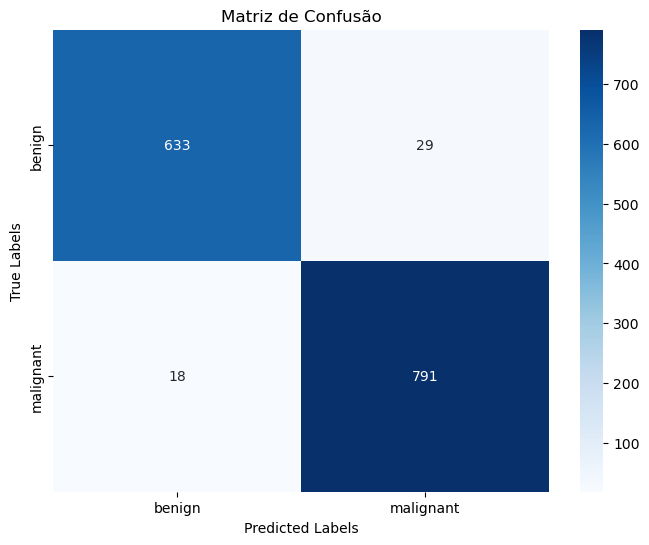

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

# Mostrar a matriz de confusão
plt.figure(figsize=(8, 6))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues',
            xticklabels=['benign', 'malignant'],
            yticklabels=['benign', 'malignant'])
plt.ylabel('True Labels')
plt.xlabel('Predicted Labels')
plt.title('Matriz de Confusão')
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


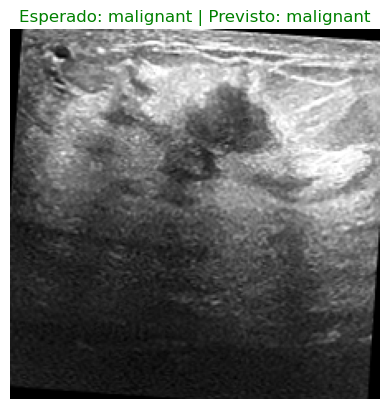

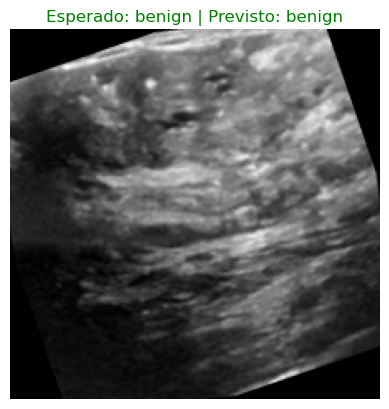

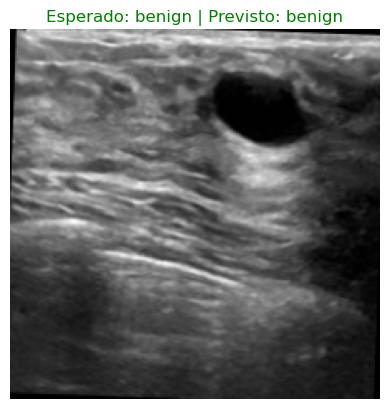

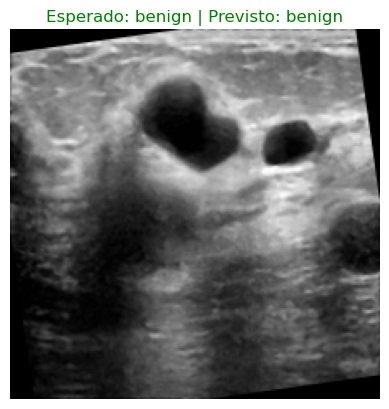

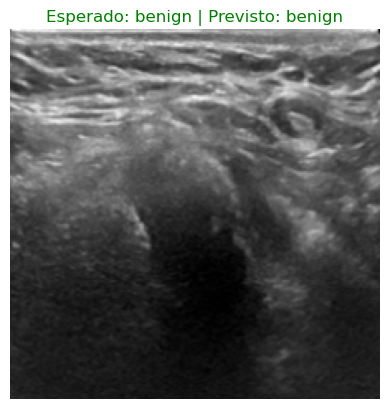

In [22]:
import matplotlib.pyplot as plt
import numpy as np

# Dicionário com as duas classes
class_names = {0: 'benign', 1: 'malignant'}

# Número de amostras que você quer prever
num_samples = 5

# Predição
predictions = model.predict(X_test[:num_samples])
predicted_classes = np.argmax(predictions, axis=1)

# Mostrar as imagens com a classe real e a prevista
for i in range(num_samples):
    plt.imshow(X_test[i].squeeze(), cmap='gray')  # .squeeze() remove canal extra se tiver
    esperado = class_names[y_test[i]]
    previsto = class_names[predicted_classes[i]]
    cor_titulo = 'green' if esperado == previsto else 'red'
    
    plt.title(f"Esperado: {esperado} | Previsto: {previsto}", color=cor_titulo)
    plt.axis('off')
    plt.show()


In [23]:
import os
import cv2
import numpy as np

# Caminhos das pastas
benign_path = '/home/pc/Projeto/Ultrasound Breast Images for Breast Cancer/ultrasound_dataset/val/benign'
malignant_path = '/home/pc/Projeto/Ultrasound Breast Images for Breast Cancer/ultrasound_dataset/val/malignant'

# Parâmetros
img_sz = 224
class_names = {0: 'benign', 1: 'malignant'}

def load_images_from_folder(folder_path, label):
    images = []
    labels = []

    for file in os.listdir(folder_path):
        img_path = os.path.join(folder_path, file)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

        if img is not None:
            img = cv2.resize(img, (img_sz, img_sz))
            img = img.astype('float32') / 255.0
            img = np.expand_dims(img, axis=-1)  # (224, 224, 1)

            images.append(img)
            labels.append(label)

    return images, labels


In [24]:
benign_imgs, benign_labels = load_images_from_folder(benign_path, 0)
malignant_imgs, malignant_labels = load_images_from_folder(malignant_path, 1)

X_val = np.array(benign_imgs + malignant_imgs)
y_val = np.array(benign_labels + malignant_labels)

print(f'Total de imagens: {X_val.shape[0]}')
print(f'Benign: {np.sum(y_val == 0)} | Malignant: {np.sum(y_val == 1)}')


Total de imagens: 900
Benign: 500 | Malignant: 400


In [25]:
loss, accuracy = model.evaluate(X_val, y_val, verbose=0)
print(f"Accuracy on test set: {accuracy*100:.2f}%")

Accuracy on test set: 85.11%


In [26]:
from sklearn.metrics import confusion_matrix

# Predição
y_pred_probs = model.predict(X_val)
y_pred_classes = np.argmax(y_pred_probs, axis=1)

# Matriz de confusão
conf_mat = confusion_matrix(y_val, y_pred_classes)

29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step


In [27]:
from sklearn.metrics import classification_report
import numpy as np

# 🔹 Predições no conjunto correto (900 imagens)
y_pred_probs = model.predict(X_val)
y_pred_classes = np.argmax(y_pred_probs, axis=1)

# 🔹 Checagem de consistência (ESSENCIAL)
print(len(y_val), len(y_pred_classes))  # Deve ser: 900 900

# 🔹 Relatório de classificação
print(classification_report(
    y_val,
    y_pred_classes,
    target_names=['benign', 'malignant']
))

29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
900 900
              precision    recall  f1-score   support

      benign       0.85      0.89      0.87       500
   malignant       0.86      0.80      0.83       400

    accuracy                           0.85       900
   macro avg       0.85      0.85      0.85       900
weighted avg       0.85      0.85      0.85       900



29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
900 900


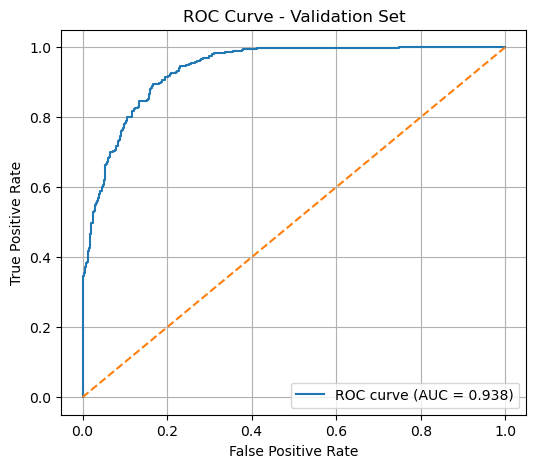

In [28]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# 🔹 1. Recalcular predições com o conjunto correto (900 imagens)
y_pred_probs = model.predict(X_val)

# 🔹 2. Pegar probabilidade da classe positiva (malignant = 1)
y_scores = y_pred_probs[:, 1]

# 🔹 3. Conferência (boa prática)
print(len(y_val), len(y_scores))  # Deve ser: 900 900

# 🔹 4. Curva ROC
fpr, tpr, _ = roc_curve(y_val, y_scores)
roc_auc = auc(fpr, tpr)

# 🔹 5. Plot
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Validation Set')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

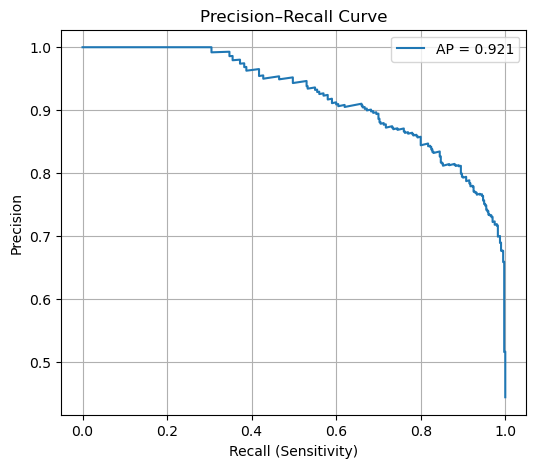

In [29]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, _ = precision_recall_curve(y_val, y_scores)
ap_score = average_precision_score(y_val, y_scores)

plt.figure(figsize=(6, 5))
plt.plot(recall, precision, label=f'AP = {ap_score:.3f}')
plt.xlabel('Recall (Sensitivity)')
plt.ylabel('Precision')
plt.title('Precision–Recall Curve')
plt.legend()
plt.grid(True)
plt.show()


In [30]:
print(len(y_val), len(y_pred_classes))

900 900


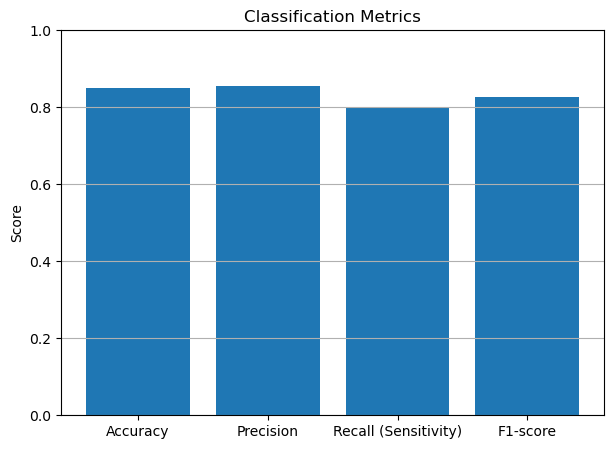

In [31]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_val, y_pred_classes)
precision = precision_score(y_val, y_pred_classes)
recall = recall_score(y_val, y_pred_classes)   # Sensibilidade (malignant)
f1 = f1_score(y_val, y_pred_classes)

metrics = {
    'Accuracy': accuracy,
    'Precision': precision,
    'Recall (Sensitivity)': recall,
    'F1-score': f1
}

plt.figure(figsize=(7, 5))
plt.bar(metrics.keys(), metrics.values())
plt.ylim(0, 1)
plt.ylabel('Score')
plt.title('Classification Metrics')
plt.grid(axis='y')
plt.show()


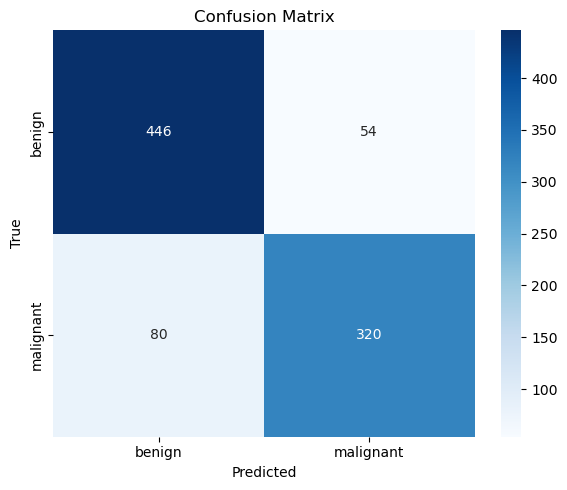

In [32]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_val, y_pred_classes)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['benign', 'malignant'],
    yticklabels=['benign', 'malignant']
)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()


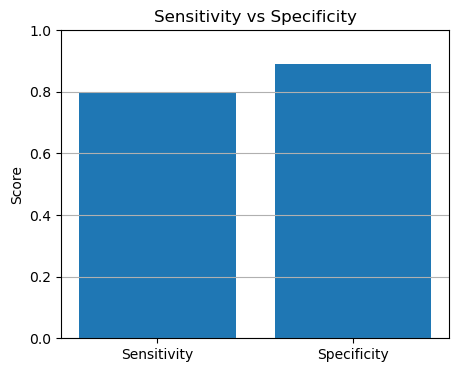

In [33]:
tn, fp, fn, tp = cm.ravel()

sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)

plt.figure(figsize=(5, 4))
plt.bar(['Sensitivity', 'Specificity'], [sensitivity, specificity])
plt.ylim(0, 1)
plt.ylabel('Score')
plt.title('Sensitivity vs Specificity')
plt.grid(axis='y')
plt.show()


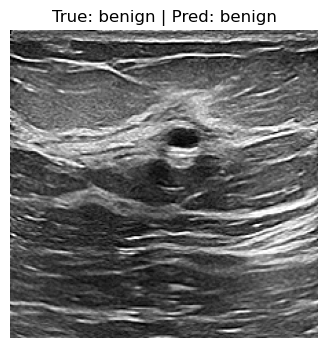

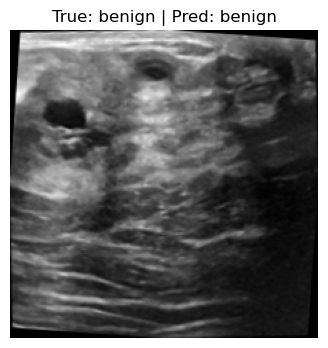

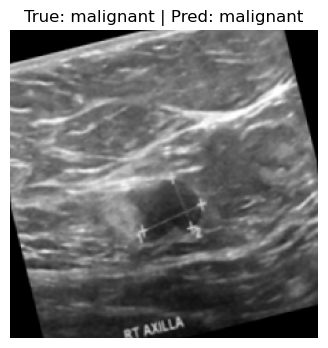

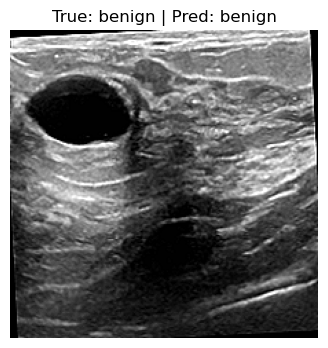

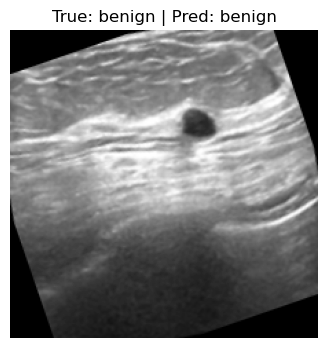

In [34]:
import numpy as np
import matplotlib.pyplot as plt

# Número de imagens para visualização
num_images = 5

# (Opcional) Para reprodutibilidade
np.random.seed(42)

for _ in range(num_images):
    # Índice aleatório
    random_idx = np.random.randint(0, len(X_val))

    # Imagem
    img = X_val[random_idx].squeeze()

    # Rótulos
    true_label = class_names[y_val[random_idx]]
    pred_label = class_names[y_pred_classes[random_idx]]

    # Plot
    plt.figure(figsize=(4, 4))
    plt.imshow(img, cmap='gray')
    plt.title(f"True: {true_label} | Pred: {pred_label}")
    plt.axis('off')
    plt.show()
